In [28]:
import os

from dotenv import load_dotenv

load_dotenv()

True

In [29]:
from langchain_community.document_loaders import PyPDFLoader

In [30]:
import os
import glob

DOCS_DIR = "sampledocs"
INDEX_DIR = "faiss_index"

print(os.path.abspath(DOCS_DIR))

c:\Users\Anshu\OneDrive\Documents\rag_example\sampledocs


In [31]:
pdf_files = glob.glob(
    os.path.join(DOCS_DIR, "*.pdf")
)

print("PDF files found:")

for pdf in pdf_files:
    print(os.path.abspath(pdf))

PDF files found:
c:\Users\Anshu\OneDrive\Documents\rag_example\sampledocs\rag_test_document.pdf


In [32]:
documents = []

for path in pdf_files:
    loader = PyPDFLoader(path)
    pages = loader.load()

    documents.extend(pages)

print(f"{len(documents)} pages loaded")

2 pages loaded


In [33]:
for doc in documents[:2]:
    print("SOURCE:", doc.metadata.get("source"))
    print("PAGE:", doc.metadata.get("page"))
    print()
    print(doc.page_content[:1000])
    print("=" * 80)

SOURCE: sampledocs\rag_test_document.pdf
PAGE: 0

RAG Test Document
Use this PDF to test PDF ingestion, chunking, embeddings, FAISS retrieval, and your LangGraph
agent.
1. Artificial Project Fact
Project Name: BananaGraph
Created: 2026
Creator: Anshu Kumar
Number of Nodes: 47
Primary Color: Purple
Purpose: BananaGraph is a fictional graph framework created specifically for testing
retrieval-augmented generation systems.
2. Artificial Person Fact
Name: Vikas Sharma
Role: Documentation Engineer
Favorite Tool: FAISS
Office: Chandigarh
Special Note: Vikas maintains the fictional BananaGraph documentation.
3. Artificial Product Fact
Product: RAGBox 9000
Version: 7.4.2
Maximum Context: 18,500 tokens
Embedding Model: BananaEmbed-X
Launch Date: 14 August 2026
4. Retrieval Test Facts
 Question
Expected retrieved fact
Who created BananaGraph?
Anshu Kumar
How many nodes does BananaGraph have?
47
What color is BananaGraph?
Purple
Who maintains BananaGraph documentation?
Vikas Sharma
What tool does

In [34]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50
)

chunks = text_splitter.split_documents(documents)

print(f"{len(chunks)} chunks")

4 chunks


In [35]:
for i, chunk in enumerate(chunks[:5]):
    print(f"\n===== CHUNK {i + 1} =====")
    print("Source:", chunk.metadata.get("source"))
    print("Page:", chunk.metadata.get("page"))
    print(chunk.page_content)


===== CHUNK 1 =====
Source: sampledocs\rag_test_document.pdf
Page: 0
RAG Test Document
Use this PDF to test PDF ingestion, chunking, embeddings, FAISS retrieval, and your LangGraph
agent.
1. Artificial Project Fact
Project Name: BananaGraph
Created: 2026
Creator: Anshu Kumar
Number of Nodes: 47
Primary Color: Purple
Purpose: BananaGraph is a fictional graph framework created specifically for testing
retrieval-augmented generation systems.
2. Artificial Person Fact
Name: Vikas Sharma
Role: Documentation Engineer
Favorite Tool: FAISS
Office: Chandigarh

===== CHUNK 2 =====
Source: sampledocs\rag_test_document.pdf
Page: 0
Favorite Tool: FAISS
Office: Chandigarh
Special Note: Vikas maintains the fictional BananaGraph documentation.
3. Artificial Product Fact
Product: RAGBox 9000
Version: 7.4.2
Maximum Context: 18,500 tokens
Embedding Model: BananaEmbed-X
Launch Date: 14 August 2026
4. Retrieval Test Facts
 Question
Expected retrieved fact
Who created BananaGraph?
Anshu Kumar
How many node

In [36]:
from langchain_huggingface import HuggingFaceEmbeddings

embedding = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 972.29it/s]


In [37]:
from langchain_community.vectorstores import FAISS

vectorstore = FAISS.from_documents(
    chunks,
    embedding
)

In [38]:
vectorstore.save_local(INDEX_DIR)

print(f"Index saved to {INDEX_DIR}/")

Index saved to faiss_index/


In [39]:
retriever = vectorstore.as_retriever(
    search_kwargs={"k": 3}
)

docs = retriever.invoke("What is artificial intelligence?")
for doc in docs:
    print("=" * 80)
    print("SOURCE:", doc.metadata.get("source"))
    print("PAGE:", doc.metadata.get("page"))
    print(doc.page_content)

SOURCE: sampledocs\rag_test_document.pdf
PAGE: 0
RAG Test Document
Use this PDF to test PDF ingestion, chunking, embeddings, FAISS retrieval, and your LangGraph
agent.
1. Artificial Project Fact
Project Name: BananaGraph
Created: 2026
Creator: Anshu Kumar
Number of Nodes: 47
Primary Color: Purple
Purpose: BananaGraph is a fictional graph framework created specifically for testing
retrieval-augmented generation systems.
2. Artificial Person Fact
Name: Vikas Sharma
Role: Documentation Engineer
Favorite Tool: FAISS
Office: Chandigarh
SOURCE: sampledocs\rag_test_document.pdf
PAGE: 1
There is intentionally no information in this document about a person named Rahul Mehta. Ask your
agent a question about Rahul Mehta and verify that it does not invent an answer from this PDF.
Recommended test: Put this file in your sampledocs folder, run your PDF loader, print the number of pages and chunks,
build the FAISS index, then ask: "How many nodes does BananaGraph have?" Your search_docs tool should r

In [50]:
from langchain_core.tools import tool
@tool
def add(a: int, b: int) -> int:
    """Add two integers."""
    return a + b
@tool
def mult(a: int, b: int) -> int:
    """multiply two integers."""
    return a * b
@tool
def divide(a: int, b: int) -> float:
    """Divide two integers."""
    return a / b

@tool
def search_docs(query: str) -> str:
    """Search the PDF knowledge base for relevant information."""

    embeddings = HuggingFaceEmbeddings(
        model_name="sentence-transformers/all-MiniLM-L6-v2"
    )

    vectorstore = FAISS.load_local(
        INDEX_DIR,
        embeddings,
        allow_dangerous_deserialization=True
    )

    docs = vectorstore.as_retriever(
        search_kwargs={"k": 3}
    ).invoke(query)

    results = []

    for doc in docs:
        results.append(
            f"Source: {doc.metadata.get('source')}\n"
            f"Page: {doc.metadata.get('page')}\n"
            f"Content:\n{doc.page_content}"
        )

    return "\n\n---\n\n".join(results)

In [51]:
tools = [
    add,
    mult,
    divide,
    search_docs
]

tools_by_name = {
    tool.name: tool
    for tool in tools
}

In [52]:
from langchain_groq import ChatGroq

model = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0
)

model_with_tools = model.bind_tools(tools)

In [53]:
import operator

from typing import Annotated
from typing_extensions import TypedDict

from langchain_core.messages import AnyMessage


class MessageState(TypedDict):
    message: Annotated[list[AnyMessage], operator.add]
    llm_calls: int


In [54]:
from langchain_core.messages import SystemMessage


def llm_call(state: MessageState) -> dict:

    messages = [
        SystemMessage(
            content=(
                "You are a helpful assistant that can perform arithmetic "
                "and answer questions about AI/ML concepts.\n\n"

                "Rules:\n"
                "1. For AI/ML questions, ALWAYS use search_docs first.\n"
                "2. Answer using the retrieved document context.\n"
                "3. Do not invent information that is not in the retrieved context.\n"
                "4. For calculations, use the appropriate math tool."
            )
        )
    ] + state["message"]

    print("\n" + "=" * 80)
    print("LLM CALL")
    print("=" * 80)

    for i, msg in enumerate(messages):

        print(f"\n--- Message {i + 1} ---")
        print("Type:", type(msg).__name__)
        print("Content:")
        print(msg.content)

        if hasattr(msg, "tool_calls") and msg.tool_calls:
            print("Tool calls:", msg.tool_calls)

    response = model_with_tools.invoke(messages)

    print("\n--- LLM RESPONSE ---")
    print("Content:", response.content)

    if response.tool_calls:
        print("Tool calls:")

        for tc in response.tool_calls:
            print("Tool:", tc["name"])
            print("Args:", tc["args"])

    print("=" * 80)

    return {
        "message": [response],
        "llm_calls": state.get("llm_calls", 0) + 1
    }

In [55]:
from langchain_core.messages import ToolMessage


def tool_node(state: MessageState) -> dict:

    results = []

    for tool_call in state["message"][-1].tool_calls:

        tool = tools_by_name[tool_call["name"]]

        observation = tool.invoke(
            tool_call["args"]
        )

        results.append(
            ToolMessage(
                content=str(observation),
                tool_call_id=tool_call["id"]
            )
        )

    return {
        "message": results
    }

In [56]:
from typing import Literal
from langgraph.graph import END


def should_continue(
    state: MessageState
) -> Literal["tool_node", "__end__"]:

    last = state["message"][-1]

    if hasattr(last, "tool_calls") and last.tool_calls:
        return "tool_node"

    return END

In [57]:
from langgraph.graph import StateGraph, START, END


agent_builder = StateGraph(MessageState)

agent_builder.add_node(
    "llm_call",
    llm_call
)

agent_builder.add_node(
    "tool_node",
    tool_node
)

agent_builder.add_edge(
    START,
    "llm_call"
)

agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)

agent_builder.add_edge(
    "tool_node",
    "llm_call"
)

agent = agent_builder.compile()

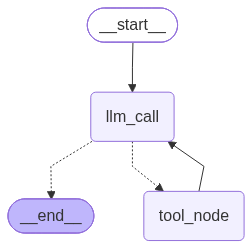

In [58]:
from IPython.display import Image, display

display(
    Image(
        agent.get_graph().draw_mermaid_png()
    )
)

In [60]:
from langchain_core.messages import (
    HumanMessage,
    AIMessage,
    ToolMessage
)


def run_agent(question: str):

    result = agent.invoke({
        "message": [
            HumanMessage(content=question)
        ],
        "llm_calls": 0
    })

    print("\n" + "=" * 80)
    print("FINAL RESULT")
    print("=" * 80)

    print("Q:", question)

    for msg in result["message"]:

        if isinstance(msg, AIMessage):

            if msg.tool_calls:
                for tc in msg.tool_calls:
                    print(
                        f"\nTool: {tc['name']}"
                    )
                    print(
                        f"Args: {tc['args']}"
                    )

        elif isinstance(msg, ToolMessage):

            print("\nTool result:")
            print(msg.content[:1000])

    print("\nA:")
    print(result["message"][-1].content)

    print(
        "\nLLM calls:",
        result["llm_calls"]
    )

In [62]:
run_agent(
    "What is BananaGraph and how many nodes does it contain?"
)


LLM CALL

--- Message 1 ---
Type: SystemMessage
Content:
You are a helpful assistant that can perform arithmetic and answer questions about AI/ML concepts.

Rules:
1. For AI/ML questions, ALWAYS use search_docs first.
2. Answer using the retrieved document context.
3. Do not invent information that is not in the retrieved context.
4. For calculations, use the appropriate math tool.

--- Message 2 ---
Type: HumanMessage
Content:
What is BananaGraph and how many nodes does it contain?

--- LLM RESPONSE ---
Content: 
Tool calls:
Tool: search_docs
Args: {'query': 'BananaGraph nodes'}


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 842.74it/s]



LLM CALL

--- Message 1 ---
Type: SystemMessage
Content:
You are a helpful assistant that can perform arithmetic and answer questions about AI/ML concepts.

Rules:
1. For AI/ML questions, ALWAYS use search_docs first.
2. Answer using the retrieved document context.
3. Do not invent information that is not in the retrieved context.
4. For calculations, use the appropriate math tool.

--- Message 2 ---
Type: HumanMessage
Content:
What is BananaGraph and how many nodes does it contain?

--- Message 3 ---
Type: AIMessage
Content:

Tool calls: [{'name': 'search_docs', 'args': {'query': 'BananaGraph nodes'}, 'id': 'fc_7f35848d-8575-45bd-b056-4d4b0a6ab180', 'type': 'tool_call'}]

--- Message 4 ---
Type: ToolMessage
Content:
Source: sampledocs\rag_test_document.pdf
Page: 1
Content:
There is intentionally no information in this document about a person named Rahul Mehta. Ask your
agent a question about Rahul Mehta and verify that it does not invent an answer from this PDF.
Recommended test: Put